# Nigerian Pidgin Sentiment Analyzer

## Notebook 02 — Data Preprocessing


Objective

Prepare the raw NaijaSenti dataset for Machine Learning by cleaning,
normalizing and transforming tweets into a format suitable for model training.

In [1]:
# Import Libraries

import pandas as pd
import numpy as numpy

import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import nltk

In [2]:
# Download NLTK Resources

nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# Load Dataset

train_df = pd.read_csv(
    "../dataset/raw/train.tsv",
    sep='\t'
)

In [4]:
train_df.head()

,tweet,label
0,yeah ‍️the guy wants to trend dat was why e jo...,negative
1,this life is so funny sef you will work hard a...,negative
2,dis is unfair of urcompany goingtowks nw ive b...,negative
3,lil wayne don vex me im actually not excited a...,negative
4,dis is unfair of ur company going to wks nw iv...,negative


In [5]:
# Check shape

train_df.shape

(5121, 2)

In [6]:
# Duplicate Removal

train_df = train_df.drop_duplicates()

In [7]:
train_df.shape

(4641, 2)

In [8]:
train_df.duplicated().sum()

np.int64(0)

In [9]:
# Text Cleaning

def clean_text(text):
     # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)


     # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtags symbol but keep words
    text = re.sub(r"#", "", text)


    # Remove numbers
    text = re.sub(r"\d+", "", text)


    # Remove punctuation only
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )


     # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)
    

    return text.strip()

In [10]:
train_df["clean_text"] = train_df["tweet"].apply(clean_text)

In [11]:
train_df[
    ["tweet", "clean_text"]
].head()

,tweet,clean_text
0,yeah ‍️the guy wants to trend dat was why e jo...,yeah ‍️the guy wants to trend dat was why e jo...
1,this life is so funny sef you will work hard a...,this life is so funny sef you will work hard a...
2,dis is unfair of urcompany goingtowks nw ive b...,dis is unfair of urcompany goingtowks nw ive b...
3,lil wayne don vex me im actually not excited a...,lil wayne don vex me im actually not excited a...
4,dis is unfair of ur company going to wks nw iv...,dis is unfair of ur company going to wks nw iv...


In [12]:
# Tokenization

train_df["tokens"] = train_df["clean_text"].apply(word_tokenize)

In [13]:
train_df[
    ["clean_text", "tokens"]
].head()

,clean_text,tokens
0,yeah ‍️the guy wants to trend dat was why e jo...,"[yeah, ‍️the, guy, wants, to, trend, dat, was,..."
1,this life is so funny sef you will work hard a...,"[this, life, is, so, funny, sef, you, will, wo..."
2,dis is unfair of urcompany goingtowks nw ive b...,"[dis, is, unfair, of, urcompany, goingtowks, n..."
3,lil wayne don vex me im actually not excited a...,"[lil, wayne, don, vex, me, im, actually, not, ..."
4,dis is unfair of ur company going to wks nw iv...,"[dis, is, unfair, of, ur, company, going, to, ..."


In [14]:
# Stopword Removal

stop_words = set(stopwords.words("english"))

In [15]:
train_df["tokens"].apply(len).describe()

count    4641.000000
mean       24.472312
std        12.889423
min         3.000000
25%        15.000000
50%        22.000000
75%        32.000000
max        66.000000
Name: tokens, dtype: float64

In [16]:
all_words = [
    word
    for tokens in train_df["tokens"]
    for word in tokens
]

vocab_size = len(set(all_words))

vocab_size

10591

In [17]:
# Check Most Common Words

from collections import Counter

word_frequency = Counter(all_words)

word_frequency.most_common(20)

[('dey', 4025),
 ('i', 3279),
 ('na', 2437),
 ('you', 1926),
 ('me', 1735),
 ('no', 1699),
 ('for', 1667),
 ('the', 1612),
 ('to', 1490),
 ('go', 1427),
 ('like', 1371),
 ('this', 1350),
 ('my', 1324),
 ('and', 1253),
 ('e', 1251),
 ('don', 1188),
 ('be', 1031),
 ('wey', 1019),
 ('say', 928),
 ('una', 759)]

In [18]:
from collections import Counter

all_words = [
    word
    for tokens in train_df["tokens"]
    for word in tokens
]

vocab_size = len(set(all_words))

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 10591


In [19]:
word_frequency = Counter(all_words)

word_frequency.most_common(20)

[('dey', 4025),
 ('i', 3279),
 ('na', 2437),
 ('you', 1926),
 ('me', 1735),
 ('no', 1699),
 ('for', 1667),
 ('the', 1612),
 ('to', 1490),
 ('go', 1427),
 ('like', 1371),
 ('this', 1350),
 ('my', 1324),
 ('and', 1253),
 ('e', 1251),
 ('don', 1188),
 ('be', 1031),
 ('wey', 1019),
 ('say', 928),
 ('una', 759)]

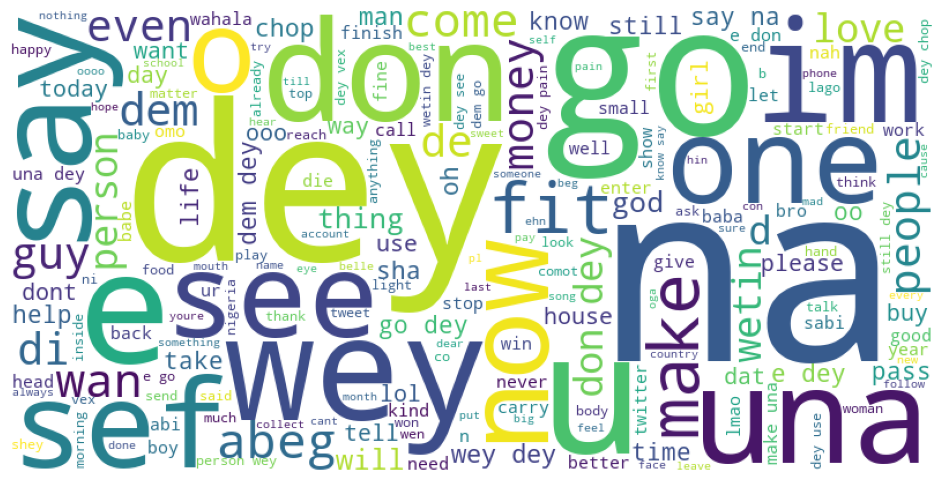

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


text =  " ".join(all_words)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)


plt.figure(figsize=(12, 6))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

# Stemming/Lemmatization Decision


Stemming and lemmatization were not applied because Nigerian Pidgin
contains unique linguistic expressions where reducing words may remove
important contextual information required for sentiment classification.


In [21]:
train_df["final_text"] = train_df["tokens"].apply(
    lambda x: " ".join(x)
    
)

In [22]:
train_df[["final_text", "label"]].head()

,final_text,label
0,yeah ‍️the guy wants to trend dat was why e jo...,negative
1,this life is so funny sef you will work hard a...,negative
2,dis is unfair of urcompany goingtowks nw ive b...,negative
3,lil wayne don vex me im actually not excited a...,negative
4,dis is unfair of ur company going to wks nw iv...,negative


In [23]:
processed_df = train_df[
    [
          "final_text",
            "label"
    ]
]

In [24]:
train_df.head()

,tweet,label,clean_text,tokens,final_text
0,yeah ‍️the guy wants to trend dat was why e jo...,negative,yeah ‍️the guy wants to trend dat was why e jo...,"[yeah, ‍️the, guy, wants, to, trend, dat, was,...",yeah ‍️the guy wants to trend dat was why e jo...
1,this life is so funny sef you will work hard a...,negative,this life is so funny sef you will work hard a...,"[this, life, is, so, funny, sef, you, will, wo...",this life is so funny sef you will work hard a...
2,dis is unfair of urcompany goingtowks nw ive b...,negative,dis is unfair of urcompany goingtowks nw ive b...,"[dis, is, unfair, of, urcompany, goingtowks, n...",dis is unfair of urcompany goingtowks nw ive b...
3,lil wayne don vex me im actually not excited a...,negative,lil wayne don vex me im actually not excited a...,"[lil, wayne, don, vex, me, im, actually, not, ...",lil wayne don vex me im actually not excited a...
4,dis is unfair of ur company going to wks nw iv...,negative,dis is unfair of ur company going to wks nw iv...,"[dis, is, unfair, of, ur, company, going, to, ...",dis is unfair of ur company going to wks nw iv...


In [29]:
import os

os.getcwd()

'c:\\Users\\user\\Desktop\\nigerian_pidgin_sentiment_analyzer\\notebooks'

In [30]:
os.listdir()

['01_dataset_validation.ipynb', '02_data-preprocessing.ipynb']

In [31]:
import os

os.chdir("..")

os.getcwd()

'c:\\Users\\user\\Desktop\\nigerian_pidgin_sentiment_analyzer'

In [32]:
os.listdir()

['.git',
 '.gitignore',
 'dataset',
 'documentation',
 'models',
 'myenv',
 'notebooks',
 'outputs',
 'README.md',
 'requirements.txt',
 'src']

In [33]:
processed_df.to_csv(
    "dataset/processed/train_processed.csv",
    index=False
)

In [34]:
processed_df.to_csv(
    "dataset/processed/test_processed.csv",
    index=False
)

In [35]:
processed_df.to_csv(
    "dataset/processed/dev_processed.csv",
    index=False
)

In [36]:
processed_df.head()

,final_text,label
0,yeah ‍️the guy wants to trend dat was why e jo...,negative
1,this life is so funny sef you will work hard a...,negative
2,dis is unfair of urcompany goingtowks nw ive b...,negative
3,lil wayne don vex me im actually not excited a...,negative
4,dis is unfair of ur company going to wks nw iv...,negative


In [37]:
processed_df.shape

(4641, 2)

In [38]:
processed_df.info()

<class 'pandas.DataFrame'>
Index: 4641 entries, 0 to 5120
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   final_text  4641 non-null   str  
 1   label       4641 non-null   str  
dtypes: str(2)
memory usage: 108.8 KB


In [40]:
print("Original dataset:", train_df.shape)
print("Processed dataset:", processed_df.shape)

Original dataset: (4641, 5)
Processed dataset: (4641, 2)


## Day 2: Text Preprocessing Summary

Completed preprocessing steps:

- Removed duplicate records
- Validated missing values
- Cleaned Nigerian Pidgin text
- Tokenized tweets
- Removed stopwords
- Analysed vocabulary size
- Analysed word frequency
- Generated word cloud visualization
- Preserved Nigerian Pidgin linguistic structures
- Created final processed dataset for machine learning

The processed dataset is now ready for feature engineering and model development.